In [1]:
import pandas as pd

In [2]:
training_df=pd.read_csv("../Datasets/training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,...,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.4600,95.42882,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.7600,13.110001,14.0100,21.910000,0.275,0.318,0.195,0.026,1
1,10.4535,95.42859,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.7535,13.103500,14.0035,21.903500,0.275,0.318,0.195,0.026,1
2,10.4145,95.42721,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.7145,13.064501,13.9645,21.864500,0.275,0.318,0.195,0.026,1
3,9.2235,99.66392,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.4235,12.823500,13.7235,21.923500,0.273,0.324,0.201,0.020,1
4,9.2430,99.66399,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.4430,12.842999,13.7430,21.942999,0.273,0.324,0.201,0.020,1


In [3]:
training_df.shape

(113896, 31)

In [4]:
X=training_df.drop('fire',axis=1)
y=training_df['fire']

In [5]:
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import optuna
from sklearn.metrics import accuracy_score

c:\Users\abhir\anaconda3\envs\wildfire-prediction\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X_train

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,...,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
86276,23.581500,30.182863,5.0815,20.782309,0.0,0.0,0.0,0.0,0.0,1013.1,...,206.564990,29.519999,33.081500,28.081500,21.581500,18.381498,0.076,0.094,0.072,0.155
19582,16.959000,21.806984,-5.0410,11.936909,0.0,0.0,0.0,0.0,0.0,1011.3,...,263.333440,24.119999,19.809000,25.459000,21.009000,16.809000,0.005,0.088,0.150,0.186
76324,14.174001,43.637997,1.9740,11.599044,0.0,0.0,0.0,0.0,0.0,1012.2,...,304.992100,36.000000,18.273998,17.973999,17.973999,13.523999,0.136,0.151,0.166,0.264
87200,39.696500,27.070065,17.2465,39.359700,0.0,0.0,0.0,0.0,0.0,1002.9,...,136.123210,34.200000,48.746500,42.246500,39.046500,29.846500,0.018,0.125,0.034,0.081
18455,3.293500,75.322950,-0.6565,-0.988489,0.0,0.0,0.0,0.0,0.0,1022.1,...,269.157500,45.000000,6.193500,11.593500,12.393500,14.793500,0.030,0.152,0.207,0.206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76820,15.552000,10.473747,-15.4480,6.746056,0.0,0.0,0.0,0.0,0.0,1023.3,...,32.005356,72.000000,15.852001,17.752000,19.452000,21.802000,0.100,0.137,0.102,0.161
110268,20.286001,55.862114,11.1860,20.166687,0.0,0.0,0.0,0.0,0.0,1017.3,...,57.994660,9.720000,22.186000,25.886002,25.786001,22.986000,0.093,0.151,0.190,0.269
103694,22.719000,36.850560,7.2190,20.714050,0.0,0.0,0.0,0.0,0.0,1013.7,...,343.009100,12.599999,25.619001,30.569000,29.319000,26.819000,0.129,0.147,0.150,0.172
860,10.053500,99.333230,9.9535,9.476762,0.0,0.0,0.0,0.0,3.0,1018.7,...,102.804260,9.000000,9.403500,14.153500,15.403500,19.503500,0.148,0.163,0.180,0.026


In [33]:
y_train

86276     0
19582     1
76324     0
87200     0
18455     1
         ..
76820     0
110268    0
103694    0
860       1
15795     1
Name: fire, Length: 91116, dtype: int64

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

def feature_transformation(X_train, X_test):
    num_attributes = X_train.columns.tolist()
    
    numeric_pipeline = Pipeline([
        ('std_scaler', StandardScaler())
    ])
    
    encoder_pipeline = ColumnTransformer([
        ("numeric_var", numeric_pipeline, num_attributes)
    ])

    X_train_scaled = encoder_pipeline.fit_transform(X_train)
    X_test_scaled = encoder_pipeline.transform(X_test)

    return X_train_scaled, X_test_scaled, encoder_pipeline


In [8]:
X_train_scaled, X_test_scaled, encoder_pipeline = feature_transformation(X_train, X_test)

In [35]:
pd.DataFrame(X_train_scaled)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.511418,-0.402446,0.320015,0.403952,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.362920,...,0.076309,0.337853,1.312226,0.942181,0.165759,-0.061828,-0.496839,-1.113534,-1.300906,-0.770100
1,-0.301463,-0.745139,-0.985358,-0.594069,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.791550,...,0.621981,-0.026680,-0.121646,0.557944,0.057670,-0.399624,-1.383182,-1.200237,-0.403567,-0.446570
2,-0.643309,0.148061,-0.080720,-0.632190,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.577235,...,1.022415,0.775293,-0.287477,-0.538725,-0.515342,-1.105291,0.252183,-0.289862,-0.219498,0.367473
3,2.489458,-0.529804,1.888784,2.500028,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-2.791822,...,-0.600795,0.653782,3.004567,3.017574,3.463175,2.401025,-1.220894,-0.665572,-1.738071,-1.542397
4,-1.978839,1.444427,-0.419943,-2.052434,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,1.780228,...,0.677963,1.382848,-1.592573,-1.473567,-1.568948,-0.832584,-1.071090,-0.275412,0.252181,-0.237841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91111,-0.474166,-1.208830,-2.327419,-1.179750,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,2.065981,...,-1.601602,3.205513,-0.549133,-0.571251,-0.236294,0.672946,-0.197230,-0.492167,-0.955776,-0.707481
91112,0.106911,0.648201,1.107237,0.334492,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,0.637216,...,-1.351787,-0.998768,0.135150,0.620506,0.959574,0.927287,-0.284616,-0.289862,0.056607,0.419656
91113,0.405550,-0.129642,0.595662,0.396251,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.220044,...,1.387843,-0.804350,0.506028,1.306638,1.626609,1.750673,0.164797,-0.347664,-0.403567,-0.592680
91114,-1.149081,2.426789,0.948297,-0.871646,-0.050796,-0.050646,-0.00762,-0.022342,0.495661,0.970594,...,-0.921065,-1.047372,-1.245786,-1.098487,-1.000656,0.179194,0.401988,-0.116457,-0.058437,-2.116402


In [37]:
pd.DataFrame(X_test_scaled)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.572422,0.605724,1.525382,0.915391,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.505797,...,0.430712,-0.634235,0.544866,0.026019,0.165193,0.388639,0.202249,-0.159808,0.378728,0.983224
1,-0.304470,0.345181,0.436464,-0.198028,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,0.065709,...,-0.813810,-0.609933,-0.351162,-1.057316,0.402327,1.936595,0.926304,-2.269565,-2.094706,-1.438032
2,0.187616,-0.491529,-0.110445,0.176492,-0.050796,-0.050646,-0.00762,-0.022342,0.080009,0.446713,...,-0.640552,-0.974466,0.076542,0.365203,0.300185,0.316676,0.189765,-0.260961,0.344215,0.972787
3,1.034006,-1.034091,-0.517242,0.788913,-0.050796,-0.050646,-0.00762,-0.022342,0.080009,0.232399,...,0.014515,2.233425,0.940322,0.379195,0.686379,0.530524,-0.496839,-0.665572,-0.472593,-0.415260
4,0.996937,-1.151606,-0.923716,0.992980,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.362920,...,-1.408208,-0.464120,1.172377,-0.067970,-0.050324,1.034909,-0.946253,-0.824526,-0.610645,-1.469342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22775,0.118756,-0.157052,0.294353,0.163947,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.958239,...,1.009899,-1.241790,-0.632265,0.656622,1.260996,1.710610,-1.158476,-2.197313,-0.944271,-0.603116
22776,1.835901,-0.467025,1.414930,2.135014,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.339108,...,0.790261,1.480057,1.311200,0.633106,-0.072037,-1.062758,0.227216,0.129199,0.781380,1.118898
22777,0.321163,1.105675,1.680518,0.694565,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.481984,...,-1.567648,-1.193186,0.485772,1.557546,1.695050,1.570765,-0.521807,-0.766725,-1.266393,-0.770100
22778,-0.063828,-1.111592,-1.664190,-0.160796,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,0.732467,...,0.880469,-0.245400,0.006482,-1.444044,-1.549784,-0.757076,-0.634160,0.259253,-0.898254,0.544893


In [9]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [10]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42,n_jobs=-1,verbose=True, max_depth=13, min_samples_leaf=3, min_samples_split=4)
rf.fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.1s finished


RandomForestClassifier(max_depth=13, min_samples_leaf=3, min_samples_split=4,
                       n_jobs=-1, random_state=42, verbose=True)

In [11]:
# Training accuracy
y_train_pred_rf = rf.predict(X_train_scaled)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
print(f'Training Accuracy (RF): {train_accuracy_rf * 100:.2f}%')

# Testing accuracy
y_test_pred_rf = rf.predict(X_test_scaled) 
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f'Testing Accuracy (RF): {test_accuracy_rf * 100:.2f}%')


Training Accuracy (RF): 86.80%
Testing Accuracy (RF): 81.15%


[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished


In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

Precision: 81.90%
Recall: 81.15%
F1 Score: 81.02%


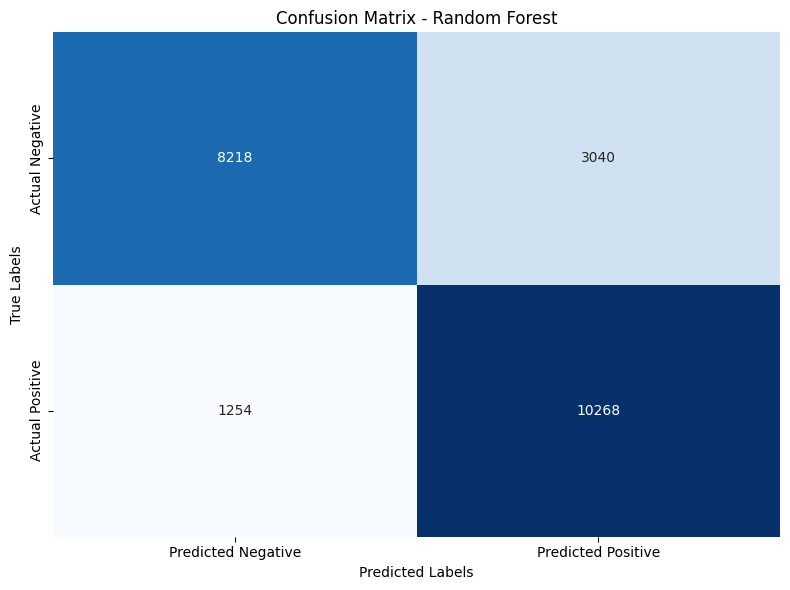

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.73      0.79     11258
           1       0.77      0.89      0.83     11522

    accuracy                           0.81     22780
   macro avg       0.82      0.81      0.81     22780
weighted avg       0.82      0.81      0.81     22780



In [19]:
# Precision, Recall, F1 (on test set)
precision = precision_score(y_test, y_test_pred_rf, average='weighted')
recall = recall_score(y_test, y_test_pred_rf, average='weighted')
f1 = f1_score(y_test, y_test_pred_rf, average='weighted')

print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_test_pred_rf))


[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished


AUC-ROC: 0.8899


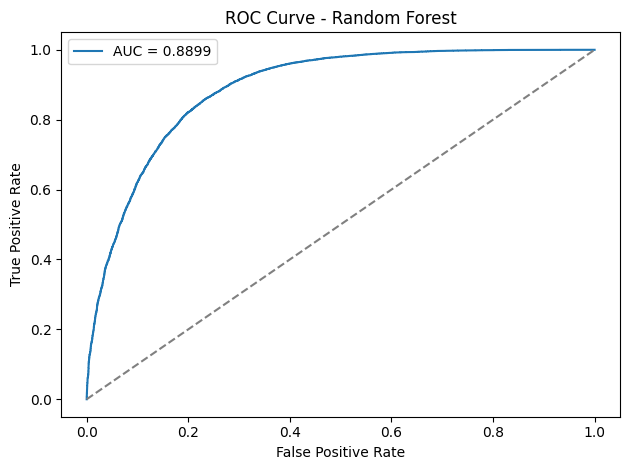

In [20]:
y_probs = rf.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f'AUC-ROC: {auc:.4f}')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
importances = rf.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)

In [22]:
scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.6s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.7s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0

CV Accuracy: 0.8020 ± 0.0026


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.2s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished


### Hyperparameter Tuning

In [23]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 300, step=50),
        max_depth=trial.suggest_int("max_depth", 10, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 6),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        random_state=42,
        n_jobs=-1
    )
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best hyperparameters:", study.best_params)
print(f"Best cross-validated accuracy: {study.best_value:.4f}")


[I 2025-04-30 14:59:25,805] A new study created in memory with name: no-name-1977edf0-a585-4094-88fa-148b1fcb6d33
[I 2025-04-30 14:59:35,964] Trial 0 finished with value: 0.8178585539312525 and parameters: {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8178585539312525.
[I 2025-04-30 14:59:49,143] Trial 1 finished with value: 0.7669344571754687 and parameters: {'n_estimators': 150, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.8178585539312525.
[I 2025-04-30 15:00:05,770] Trial 2 finished with value: 0.8008472716098161 and parameters: {'n_estimators': 150, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8178585539312525.
[I 2025-04-30 15:00:16,778] Trial 3 finished with value: 0.801538697923526 and parameters: {'n_estimators': 100, 'max_depth': 14, 'mi

Best hyperparameters: {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best cross-validated accuracy: 0.8179


In [24]:
best_params=study.best_params

In [27]:
rf = RandomForestClassifier(n_estimators=best_params['n_estimators'],
                            min_samples_split=best_params['min_samples_split'],
                            min_samples_leaf=best_params['min_samples_leaf'],
                            max_features=best_params['max_features'],
                            max_depth=best_params['max_depth'],
                            n_jobs=-1)

### Training

In [28]:
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=15, min_samples_split=4, n_estimators=150,
                       n_jobs=-1)

In [29]:
# Training accuracy
y_train_pred_rf = rf.predict(X_train_scaled)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
print(f'Training Accuracy (RF): {train_accuracy_rf * 100:.2f}%')

# Testing accuracy
y_test_pred_rf = rf.predict(X_test_scaled) 
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f'Testing Accuracy (RF): {test_accuracy_rf * 100:.2f}%')


Training Accuracy (RF): 91.82%
Testing Accuracy (RF): 83.45%


Precision: 84.18%
Recall: 83.45%
F1 Score: 83.35%


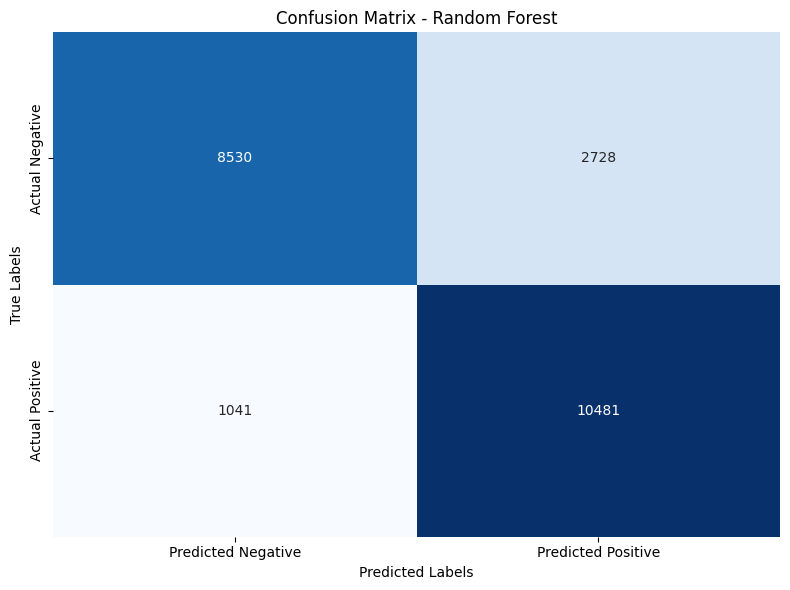

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82     11258
           1       0.79      0.91      0.85     11522

    accuracy                           0.83     22780
   macro avg       0.84      0.83      0.83     22780
weighted avg       0.84      0.83      0.83     22780



In [30]:
# Precision, Recall, F1 (on test set)
precision = precision_score(y_test, y_test_pred_rf, average='weighted')
recall = recall_score(y_test, y_test_pred_rf, average='weighted')
f1 = f1_score(y_test, y_test_pred_rf, average='weighted')

print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_test_pred_rf))


AUC-ROC: 0.9130


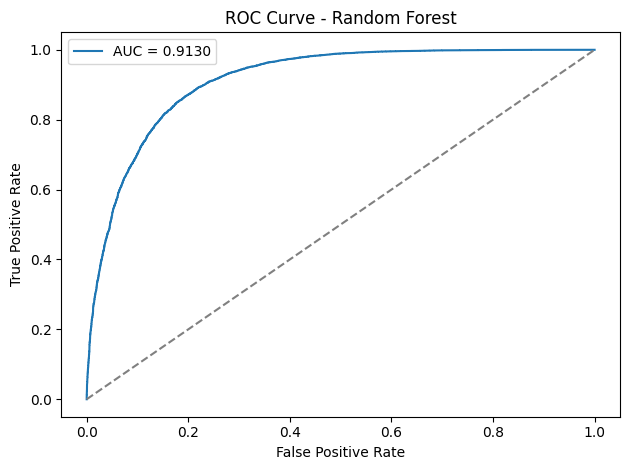

In [31]:
y_probs = rf.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f'AUC-ROC: {auc:.4f}')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()
